In [1]:
#Import block: 
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import pandas as pd
from scipy import stats, interpolate
from scipy.stats import trapezoid, chi2, gaussian_kde
from scipy.integrate import quad

from sklearn.neighbors import KernelDensity

## Problem 3: Exam in Advanced Methods in Applied Statistics
Author: Aske Roelshøj

KU-ID: KVF851

Date(s): Thurs. March 26 to Fri. March 27, 2026

## 3a

In [ ]:
data = pd.read_csv('Data/NZCities.txt', delimiter=' ', skiprows=1)
data

,City,Population,Distance,Region
0,Picton,4.3,0,Nelson-Marlborough
1,Blenheim,28.2,27,Nelson-Marlborough
2,Kaikōura,2.3,156,Canterbury
3,Christchurch,381.0,336,Canterbury
4,Ashburton,34.8,416,Canterbury
5,Dunedin,128.8,691,Otago
6,Milton,2.1,745,Otago
7,Gore,12.8,842,Southland
8,Invercargill,57.1,895,Southland
9,Bluff,1.8,918,Southland


In [3]:
pop = data['Population'].to_numpy()
dist = data['Distance'].to_numpy()

Estimated population between 405 and 430 km: 14.365018745985724


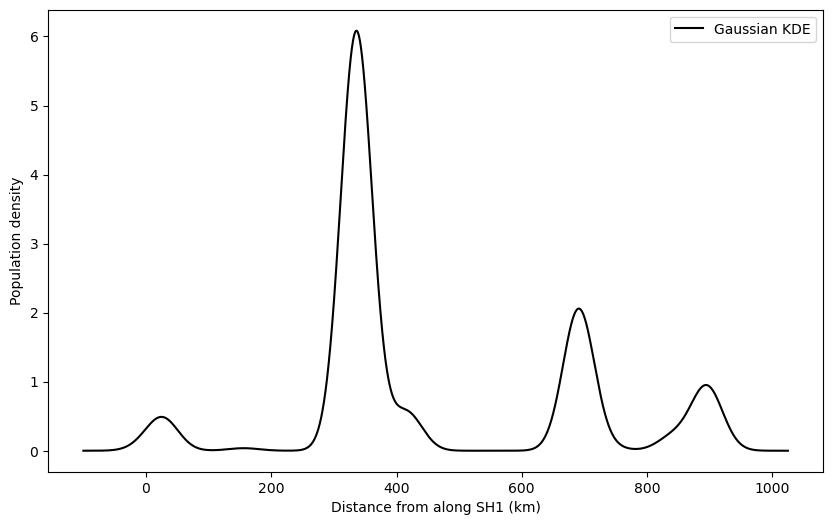

In [5]:
X = dist.reshape(-1, 1)
# Fit KDE
kde_pop = KernelDensity(kernel='gaussian', bandwidth=25).fit(X, sample_weight=pop)

# Evaluate KDE
x_vals = np.linspace(-100, 1025, 100000)
log_dens_pop = kde_pop.score_samples(x_vals.reshape(-1, 1))
density_pop = np.exp(log_dens_pop) 
pop_counts = density_pop  * np.sum(pop) # Scale by total population and bin width

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x_vals, pop_counts, color = 'k', label='Gaussian KDE')
plt.xlabel('Distance from along SH1 (km)')
plt.ylabel('Population density')
plt.legend();

mask_a = (x_vals >= 405) & (x_vals <= 430)
estimated_population = np.trapezoid(pop_counts[mask_a], x_vals[mask_a])
print("Estimated population between 405 and 430 km:", estimated_population)

## 3b

In [6]:
nm_mask = (0 < x_vals) & (x_vals < 91)
nm_ecar_density = 5.5 #pr. 1k people

ca_mask = (x_vals >= 91) & (x_vals <= 557)
ca_ecar_density = 5.8 #pr. 1k people

ot_mask = (x_vals > 557) & (x_vals <= 823)
ot_ecar_density = 6.0 #pr. 1k people

sl_mask = x_vals > 823
sl_ecar_density = 1.9 #pr. 1k people

#Calculate the number of e-cars in each region
nm_ecars = np.round(np.trapezoid(pop_counts[nm_mask], x_vals[nm_mask]) * nm_ecar_density)
ca_ecars = np.round(np.trapezoid(pop_counts[ca_mask], x_vals[ca_mask]) * ca_ecar_density)   
ot_ecars = np.round(np.trapezoid(pop_counts[ot_mask], x_vals[ot_mask]) * ot_ecar_density)
sl_ecars = np.round(np.trapezoid(pop_counts[sl_mask], x_vals[sl_mask]) * sl_ecar_density)
#Summarize in df then print as latex table:

regions = ['Nelson-Marlborough', 'Canterbury', 'Otago', 'Southland']
ecar_counts = np.array([nm_ecars, ca_ecars, ot_ecars, sl_ecars])
summary_df = pd.DataFrame({'Region': regions, 'Estimated E-Cars': ecar_counts})
print(summary_df)
print(summary_df.to_latex(index=False))

               Region  Estimated E-Cars
0  Nelson-Marlborough             144.0
1          Canterbury            2426.0
2               Otago             803.0
3           Southland             131.0
\begin{tabular}{lr}
\toprule
Region & Estimated E-Cars \\
\midrule
Nelson-Marlborough & 144.000000 \\
Canterbury & 2426.000000 \\
Otago & 803.000000 \\
Southland & 131.000000 \\
\bottomrule
\end{tabular}



## 3c 

In [ ]:
#Distribute amount of e-car of each region by population: 
ecar_density_map = {'Nelson-Marlborough': nm_ecar_density,'Canterbury': ca_ecar_density,'Otago': ot_ecar_density,'Southland': sl_ecar_density}
data['Estimated E-Cars'] = data['Population']*data['Region'].map(ecar_density_map)
e_cars_data = data['Estimated E-Cars'].to_numpy()

In [8]:
print(e_cars_data)

[  23.65  155.1    13.34 2209.8   201.84  772.8    12.6    24.32  108.49
    3.42]


In [9]:
#Print in a latex table:
print(data[['City', 'Region', 'Population', 'Estimated E-Cars']].to_latex(index=False))

\begin{tabular}{llrr}
\toprule
City & Region & Population & Estimated E-Cars \\
\midrule
Picton & Nelson-Marlborough & 4.300000 & 23.650000 \\
Blenheim & Nelson-Marlborough & 28.200000 & 155.100000 \\
Kaikōura & Canterbury & 2.300000 & 13.340000 \\
Christchurch & Canterbury & 381.000000 & 2209.800000 \\
Ashburton & Canterbury & 34.800000 & 201.840000 \\
Dunedin & Otago & 128.800000 & 772.800000 \\
Milton & Otago & 2.100000 & 12.600000 \\
Gore & Southland & 12.800000 & 24.320000 \\
Invercargill & Southland & 57.100000 & 108.490000 \\
Bluff & Southland & 1.800000 & 3.420000 \\
\bottomrule
\end{tabular}



In [10]:
bw_ecar = 35
#Now do KDE for e-cars with epanchikov kernel:
kde_ecar = KernelDensity(kernel='epanechnikov', bandwidth=bw_ecar)
kde_ecar.fit(dist.reshape(-1, 1), sample_weight=e_cars_data)
log_density_ecar = kde_ecar.score_samples(x_vals.reshape(-1, 1))
density_ecar = np.exp(log_density_ecar)
count_ecar = density_ecar * np.sum(e_cars_data) # Scale by total population and bin width

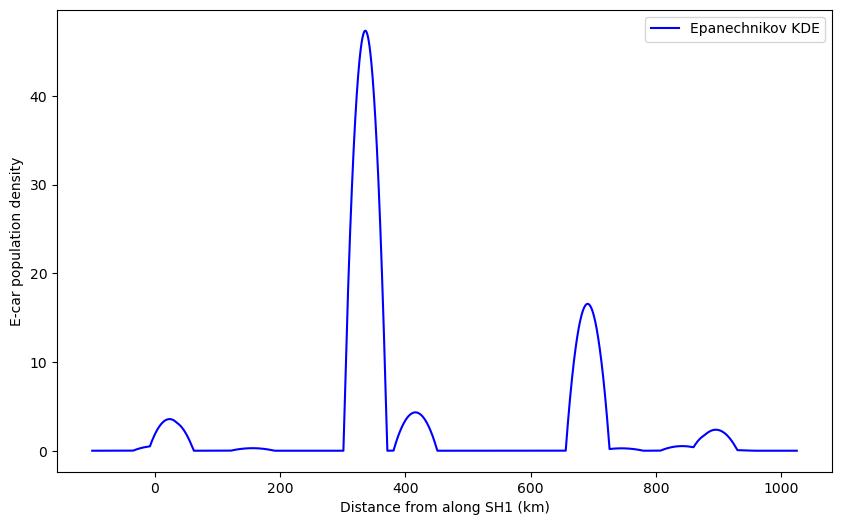

In [11]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(x_vals, count_ecar, color = 'b', label='Epanechnikov KDE')
plt.xlabel('Distance from along SH1 (km)')
plt.ylabel('E-car population density')
plt.legend();

## 3c cont.

In [12]:
cam_locs = np.array([100, 200, 300, 400, 500, 600, 700, 800])
cam_counts = np.array([12, 5, 178, 113, 42, 67, 23, 2])

In [13]:
c_bw = 50
kde_cams = KernelDensity(kernel='gaussian', bandwidth=c_bw)
kde_cams.fit(cam_locs.reshape(-1, 1), sample_weight=cam_counts)
log_density_cams = kde_cams.score_samples(x_vals.reshape(-1, 1))
density_cams = np.exp(log_density_cams)

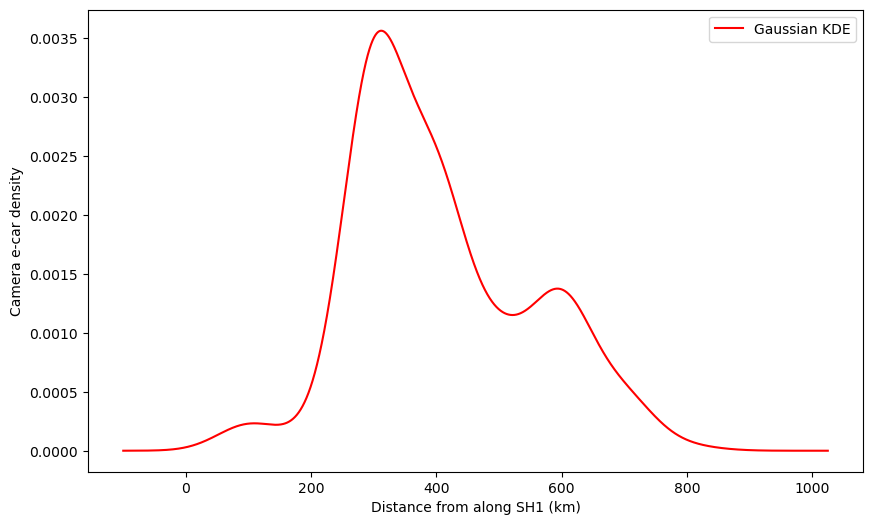

In [14]:
#Plot the KDE: 
plt.figure(figsize=(10, 6))
plt.plot(x_vals, density_cams, color = 'red', label='Gaussian KDE')
plt.xlabel('Distance from along SH1 (km)')
plt.ylabel('Camera e-car density')
plt.legend();

In [15]:
post_dist =   density_ecar*density_cams
post_dist /= np.trapezoid(post_dist, x_vals) 

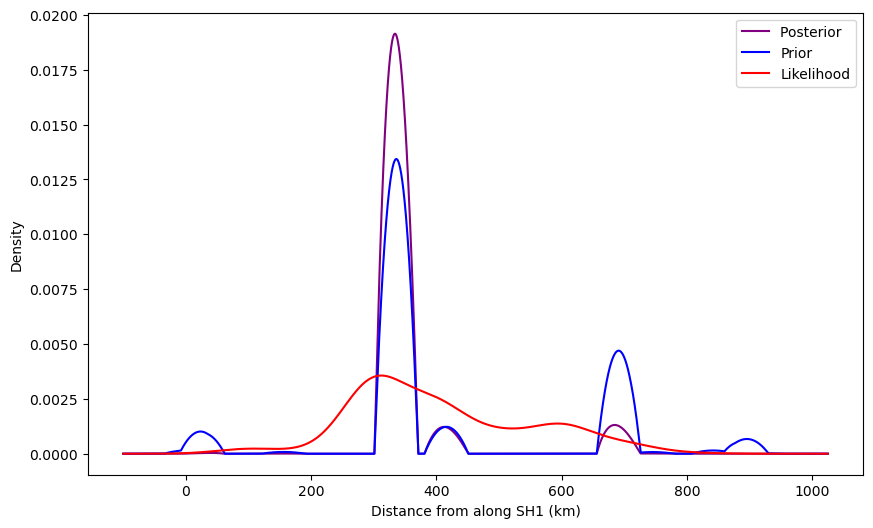

In [16]:
#Plot posterior distribution, with the prior and likelihood:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_vals, post_dist, color='purple', label='Posterior ')
ax.plot(x_vals, density_ecar, color='b', label='Prior')
ax.plot(x_vals, density_cams, color='red', label='Likelihood')
ax.set_xlabel('Distance from along SH1 (km)')
ax.set_ylabel('Density')
ax.legend();

In [31]:
#Fraction of cars between 400 and 700 km:
mask = (x_vals >= 400) & (x_vals <= 700)
fraction = np.trapezoid(post_dist[mask], x_vals[mask])
print("Fraction of e-cars between 400 and 700 km:", fraction)

Fraction of e-cars between 400 and 700 km: 0.08900875402492128
